In [11]:
#imports

import numpy as np
import matplotlib.pyplot as plt

In [12]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x



def setup_tridiagonal_matrix(x, y):

    n = len(x)

    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients

    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1]+h[i])            # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i + 1]-y[i]) / h[i]-(y[i]-y[i-1])/h[i-1])             # Right-hand side vector

    return A, B, C, D



In [14]:
X = np.array([1,2,3,4,5,6,7,8,9,10])
Y = np.array([5,8,16,20,22,34,55,64,80,125])

n = len(X)
h = np.zeros(n-1)
for i in range(n-1):
    h[i] = X[i+1] - X[i]

print(h)

A,B,C,D = setup_tridiagonal_matrix(X,Y)
print(A)
print(B)
print(C)
print(D)

solution = thomas_algorithm(A,B,C,D)
print(f"solution: {solution}")

[1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1.]
[4. 4. 4. 4. 4. 4. 4. 4.]
[1. 1. 1. 1. 1. 1. 1. 1.]
[ 30. -24. -12.  60.  54. -72.  42. 174.]
solution: [  9.32253052  -7.29012209  -4.16204218  11.93829079  16.40887902
 -23.57380688   5.8863485   42.02841287]


In [16]:
def eval_spline(X,Y):
    
    A, B, C, D = setup_tridiagonal_matrix(X, Y)
    M = np.array([0.0, * thomas_algorithm (A, B, C, D), 0.0], dtype=float)
    
    n = 0
    for i in range(len(X)-1):
        n = n + ((X[i+1]-X[i]) * 100)
    
    X2 = np.linspace(X[0],X[len(X)-1],int(n))
    Y2 = np.zeros(int(n))
    
    for i in range(len(X)-1):
        
        h = X[i+1]-X[i]
        X_interpolate = np.arange(X[i], X[i+1], 0.01)
        term1 = (M[i]/(6 * h)) * (X[i+1] - X_interpolate)**3
        term2 = (M[i+1]/(6 * h)) * (X_interpolate - X[i])**3
        term3 = (Y[i]/h - (M[i] * h)/6) * (X[i+1] - X_interpolate)
        term4 = (Y[i+1]/h - (M[i+1] * h)/6) * (X_interpolate - X[i])
        total = term1 + term2 + term3 + term4
        Y2[int(i * 100):int(i * 100 + ((X[i+1]-X[i]) * 100))] = total
        total = 0
    
    return X2,Y2
                    

(array([ 1.        ,  1.01001112,  1.02002225,  1.03003337,  1.04004449,
        1.05005562,  1.06006674,  1.07007786,  1.08008899,  1.09010011,
        1.10011123,  1.11012236,  1.12013348,  1.13014461,  1.14015573,
        1.15016685,  1.16017798,  1.1701891 ,  1.18020022,  1.19021135,
        1.20022247,  1.21023359,  1.22024472,  1.23025584,  1.24026696,
        1.25027809,  1.26028921,  1.27030033,  1.28031146,  1.29032258,
        1.3003337 ,  1.31034483,  1.32035595,  1.33036707,  1.3403782 ,
        1.35038932,  1.36040044,  1.37041157,  1.38042269,  1.39043382,
        1.40044494,  1.41045606,  1.42046719,  1.43047831,  1.44048943,
        1.45050056,  1.46051168,  1.4705228 ,  1.48053393,  1.49054505,
        1.50055617,  1.5105673 ,  1.52057842,  1.53058954,  1.54060067,
        1.55061179,  1.56062291,  1.57063404,  1.58064516,  1.59065628,
        1.60066741,  1.61067853,  1.62068966,  1.63070078,  1.6407119 ,
        1.65072303,  1.66073415,  1.67074527,  1.6807564 ,  1.6

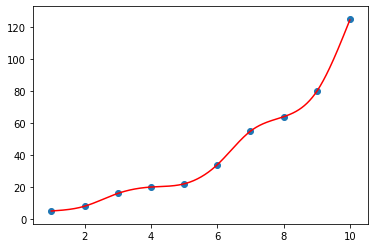

In [18]:
x_spline, y_spline = eval_spline(X,Y)

plt.figure()
plt.plot(x_spline,y_spline,color = 'red', label = 'spline line')
plt.scatter(X,Y)